# 01 · Altura promedio de los municipios de México

Calcula la **altitud media (msnm)** de cada municipio de México y la guarda en
`data/02_processed/altura_municipios.csv`, lista para usarse como **confusor topográfico**
en el estudio causal `NIVEL_SEQUIA_MAX → rendimiento`.

**Método** — estadística zonal aproximada por muestreo de puntos:

1. Se cargan los polígonos municipales del Marco Geoestadístico INEGI 2024
   (`data/01_raw/datos_lat_longitud/2024_1_00_MUN.shp`).
2. Dentro de cada municipio se genera una **rejilla regular de puntos interiores**
   (`N_PUNTOS` objetivo, siempre incluye el `representative_point`).
3. Se consulta la elevación de cada punto en el **DEM SRTM GL1 (~30 m)** vía la API
   pública de **OpenTopoData** (`https://api.opentopodata.org`) — *sin cuenta ni Earth Engine*,
   igual filosofía que la API single-pixel de Daymet en `01_confusores`.
4. Se agrega a municipio: media, mínimo, máximo, desviación estándar y nº de puntos.

> La media de una rejilla regular de puntos interiores es un estimador **insesgado**
> de la media areal del polígono; sube `N_PUNTOS` para municipios grandes o montañosos.

> **Límites de la API pública de OpenTopoData:** 100 ubicaciones por llamada, 1 llamada/seg,
> 1000 llamadas/día. Con `N_PUNTOS≈16` son ~2.5 k municipios → ~40 k puntos → ~400 llamadas.
> Hay **caché en disco** (`data/01_raw/altitud_cache/`, 1 CSV por municipio) para reanudar.


In [2]:
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point

pd.set_option('display.max_columns', 60)

# --- Parámetros -------------------------------------------------------------
PROY      = Path('/Users/jaydymarchan/Desktop/causalidad')
RUTA_SHP  = PROY / 'data/01_raw/datos_lat_longitud/2024_1_00_MUN.shp'
RUTA_CACHE = PROY / 'data/01_raw/altitud_cache'                 # 1 CSV por municipio
RUTA_OUT  = PROY / 'data/02_processed/altura_municipios.csv'    # salida final

RUTA_CACHE.mkdir(parents=True, exist_ok=True)

N_PUNTOS   = 16                       # puntos objetivo por municipio (rejilla interior)
DATASET    = 'srtm30m'                # DEM de OpenTopoData: 'srtm30m' (SRTM GL1 ~30 m) o 'aster30m'
API_URL    = 'https://api.opentopodata.org/v1/' + DATASET
LOTE       = 100                      # ubicaciones por llamada (máx. 100 en la API pública)
PAUSA      = 1.1                      # seg entre llamadas (límite: 1 req/seg)
MAX_REINT  = 4                        # reintentos por llamada (backoff)


## 1 · Polígonos municipales y puntos de muestreo

In [3]:
gdf = gpd.read_file(RUTA_SHP)[['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'NOMGEO', 'geometry']].to_crs('EPSG:4326')
gdf['idestado']    = gdf['CVE_ENT'].astype(int)
gdf['idmunicipio'] = gdf['CVE_MUN'].astype(int)
gdf = gdf.sort_values('CVEGEO').reset_index(drop=True)
print(f'{len(gdf)} municipios cargados')
gdf.head()


2478 municipios cargados


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,idestado,idmunicipio
0,01001,01,001,Aguascalientes,"POLYGON ((-102.10732 22.07476, -102.10699 22.0...",1,1
1,01002,01,002,Asientos,"POLYGON ((-102.0629 22.30175, -102.06257 22.30...",1,2
2,01003,01,003,Calvillo,"POLYGON ((-102.68534 22.10558, -102.6847 22.10...",1,3
3,01004,01,004,Cosío,"POLYGON ((-102.29739 22.45527, -102.29554 22.4...",1,4
4,01005,01,005,Jesús María,"POLYGON ((-102.35391 22.06255, -102.35312 22.0...",1,5


In [4]:
def puntos_muestreo(geom, n):
    """Rejilla regular de hasta ~n puntos DENTRO del polígono (siempre incluye el representative_point)."""
    pts = [geom.representative_point()]
    if n > 1:
        minx, miny, maxx, maxy = geom.bounds
        ancho, alto = maxx - minx, maxy - miny
        if min(ancho, alto) == 0:
            return pts
        # nº de columnas/filas proporcional a la relación de aspecto para cubrir ~n celdas
        ratio = ancho / alto
        ncol = max(2, int(round(math.sqrt(n * ratio))))
        nfil = max(2, int(round(math.sqrt(n / ratio))))
        xs = np.linspace(minx, maxx, ncol + 2)[1:-1]
        ys = np.linspace(miny, maxy, nfil + 2)[1:-1]
        dentro = [Point(x, y) for x in xs for y in ys if geom.contains(Point(x, y))]
        pts += dentro
    # dedup conservando orden
    vistos, out = set(), []
    for p in pts:
        k = (round(p.x, 6), round(p.y, 6))
        if k not in vistos:
            vistos.add(k)
            out.append(p)
    return out


filas = []
for r in gdf.itertuples():
    for k, p in enumerate(puntos_muestreo(r.geometry, N_PUNTOS)):
        filas.append((r.CVEGEO, r.idestado, r.idmunicipio, r.NOMGEO, k,
                      round(p.y, 6), round(p.x, 6)))
pts = pd.DataFrame(filas, columns=['CVEGEO', 'idestado', 'idmunicipio', 'NOMGEO', 'punto', 'lat', 'lon'])
print(f'{len(gdf)} municipios -> {len(pts)} puntos  (media {len(pts)/len(gdf):.1f} pts/municipio)')
pts.head()


2478 municipios -> 30075 puntos  (media 12.1 pts/municipio)


,CVEGEO,idestado,idmunicipio,NOMGEO,punto,lat,lon
0,01001,1,1,Aguascalientes,0,21.848588,-102.305497
1,01001,1,1,Aguascalientes,1,21.712882,-102.479416
2,01001,1,1,Aguascalientes,2,21.803497,-102.479416
3,01001,1,1,Aguascalientes,3,21.712882,-102.375689
4,01001,1,1,Aguascalientes,4,21.803497,-102.375689


## 2 · Consulta de elevación (OpenTopoData) con caché por municipio

In [5]:
def _consulta_lote(coords):
    """coords: lista de (lat, lon) (<=100). Devuelve lista de elevaciones (float o np.nan)."""
    loc = '|'.join(f'{la:.6f},{lo:.6f}' for la, lo in coords)
    for intento in range(1, MAX_REINT + 1):
        try:
            resp = requests.get(API_URL, params={'locations': loc}, timeout=60)
            if resp.status_code == 429:                      # rate limit -> espera y reintenta
                time.sleep(PAUSA * 2 * intento)
                continue
            resp.raise_for_status()
            data = resp.json()
            return [(r['elevation'] if r.get('elevation') is not None else np.nan)
                    for r in data['results']]
        except Exception as e:
            if intento == MAX_REINT:
                print(f'  ! lote fallido tras {MAX_REINT} intentos: {e}')
                return [np.nan] * len(coords)
            time.sleep(PAUSA * 2 * intento)


def elevaciones_municipio(cvegeo, sub):
    """Devuelve un DataFrame punto/lat/lon/elevation para un municipio, usando caché en disco."""
    f = RUTA_CACHE / f'{cvegeo}.csv'
    if f.exists():
        cache = pd.read_csv(f)
        if len(cache) == len(sub) and cache['elevation'].notna().any():
            return cache

    coords = list(zip(sub['lat'], sub['lon']))
    elev = []
    for i in range(0, len(coords), LOTE):
        elev += _consulta_lote(coords[i:i + LOTE])
        time.sleep(PAUSA)

    res = sub[['punto', 'lat', 'lon']].copy()
    res['elevation'] = elev
    res.to_csv(f, index=False)
    return res


In [6]:
registros = []
municipios = list(pts.groupby('CVEGEO'))
t0 = time.time()

for i, (cvegeo, sub) in enumerate(municipios, 1):
    res = elevaciones_municipio(cvegeo, sub)
    e = pd.to_numeric(res['elevation'], errors='coerce').dropna()
    meta = sub.iloc[0]
    registros.append({
        'CVEGEO': cvegeo,
        'idestado': int(meta['idestado']),
        'idmunicipio': int(meta['idmunicipio']),
        'NOMGEO': meta['NOMGEO'],
        'altitud_media_m': round(e.mean(), 1) if len(e) else np.nan,
        'altitud_min_m':   round(e.min(), 1)  if len(e) else np.nan,
        'altitud_max_m':   round(e.max(), 1)  if len(e) else np.nan,
        'altitud_std_m':   round(e.std(ddof=0), 1) if len(e) > 1 else 0.0,
        'n_puntos':        int(len(e)),
    })
    if i % 100 == 0 or i == len(municipios):
        print(f'{i:4d}/{len(municipios)}  ({time.time()-t0:5.0f}s)  ultimo: {cvegeo} {meta["NOMGEO"]}')

altura = pd.DataFrame(registros).sort_values('CVEGEO').reset_index(drop=True)
altura.head()


 100/2478  (  154s)  ultimo: 07016 Catazajá
 200/2478  (  308s)  ultimo: 07117 Montecristo de Guerrero
 300/2478  (  462s)  ultimo: 10009 Guanaceví
 400/2478  (  615s)  ultimo: 12024 Cualác
 500/2478  (  766s)  ultimo: 13039 Mineral del Monte
 600/2478  (  915s)  ultimo: 14055 Magdalena
 700/2478  ( 1065s)  ultimo: 15030 Chiconcuac
 800/2478  ( 1212s)  ultimo: 16005 Angangueo
 900/2478  ( 1361s)  ultimo: 16105 Vista Hermosa
1000/2478  ( 1511s)  ultimo: 19036 Mier y Noriega
1100/2478  ( 1666s)  ultimo: 20085 San Agustín Loxicha
1200/2478  ( 1816s)  ultimo: 20185 San Juan Cacahuatepec
1300/2478  ( 1967s)  ultimo: 20285 San Miguel Tlacamama
1400/2478  ( 2116s)  ultimo: 20385 Santa Cruz Xoxocotlán
1500/2478  ( 2269s)  ultimo: 20485 Santiago Tapextla
1600/2478  ( 2418s)  ultimo: 21015 Amozoc
1700/2478  ( 2566s)  ultimo: 21115 Quecholac
1800/2478  ( 2714s)  ultimo: 21215 Zongozotla
1900/2478  ( 2864s)  ultimo: 25010 El Fuerte
2000/2478  ( 3015s)  ultimo: 28001 Abasolo
2100/2478  ( 3164s)  ul

,CVEGEO,idestado,idmunicipio,NOMGEO,altitud_media_m,altitud_min_m,altitud_max_m,altitud_std_m,n_puntos
0,01001,1,1,Aguascalientes,1921.8,1795.0,2093.0,82.7,13
1,01002,1,2,Asientos,2038.4,1973.0,2129.0,43.4,8
2,01003,1,3,Calvillo,1975.9,1563.0,2402.0,262.0,16
3,01004,1,4,Cosío,2029.7,1939.0,2225.0,91.9,14
4,01005,1,5,Jesús María,2042.6,1863.0,2280.0,125.6,13


## 3 · Validación

In [7]:
print('municipios:', len(altura))
print('sin datos de altitud:', altura['altitud_media_m'].isna().sum())
print('n_puntos == 0        :', (altura['n_puntos'] == 0).sum())
print()
print(altura['altitud_media_m'].describe().round(1))

# Chequeos de rango físico (México: ~ -10 m costa a ~5600 m Pico de Orizaba)
raros = altura[(altura['altitud_media_m'] < -15) | (altura['altitud_media_m'] > 4500)]
print(f'\nmunicipios con altitud fuera de [-15, 4500] m: {len(raros)}')
raros


municipios: 2478
sin datos de altitud: 0
n_puntos == 0        : 0

count    2478.0
mean     1362.4
std       838.9
min        -3.0
25%       595.5
50%      1527.4
75%      2057.2
max      3249.9
Name: altitud_media_m, dtype: float64

municipios con altitud fuera de [-15, 4500] m: 0


,CVEGEO,idestado,idmunicipio,NOMGEO,altitud_media_m,altitud_min_m,altitud_max_m,altitud_std_m,n_puntos


In [8]:
# Extremos: los 5 más altos y los 5 más bajos
cols = ['CVEGEO', 'NOMGEO', 'idestado', 'altitud_media_m', 'altitud_min_m', 'altitud_max_m', 'n_puntos']
print('MÁS ALTOS');  print(altura.nlargest(5, 'altitud_media_m')[cols].to_string(index=False))
print('\nMÁS BAJOS'); print(altura.nsmallest(5, 'altitud_media_m')[cols].to_string(index=False))


MÁS ALTOS
CVEGEO                     NOMGEO  idestado  altitud_media_m  altitud_min_m  altitud_max_m  n_puntos
 15043                  Xalatlaco        15           3249.9         2812.0         3659.0        16
 15103                Tlalmanalco        15           3195.8         2426.0         4343.0        15
 15118               Zinacantepec        15           3163.2         2738.0         3608.0        14
 21023                Atzitzintla        21           3079.9         2605.0         3886.0        12
 21138 San Nicolás de los Ranchos        21           3065.2         2501.0         3932.0        12

MÁS BAJOS
CVEGEO                NOMGEO  idestado  altitud_media_m  altitud_min_m  altitud_max_m  n_puntos
 31059              Progreso        31             -3.0           -3.0           -3.0         1
 27003                Centla        27              0.3           -3.0            2.0        11
 27011                Jonuta        27              1.4           -3.0            7.0

Matplotlib is building the font cache; this may take a moment.


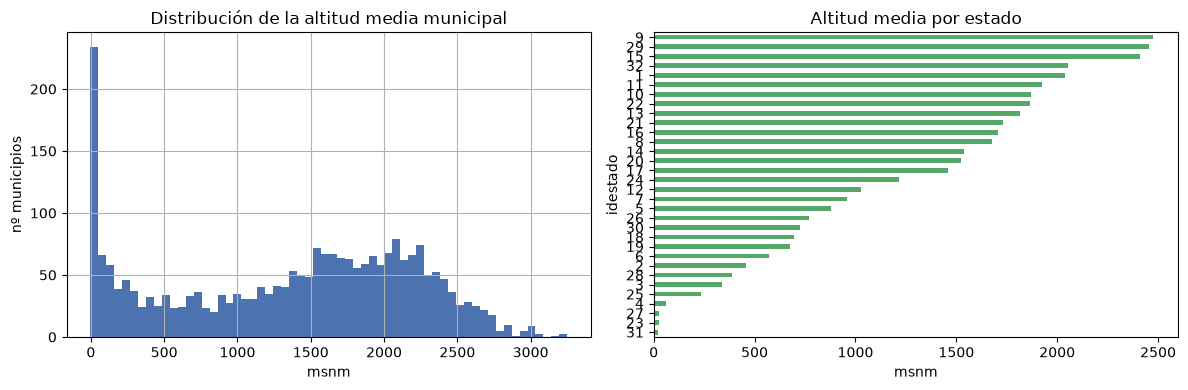

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
altura['altitud_media_m'].hist(bins=60, ax=ax[0], color='#4c72b0')
ax[0].set_title('Distribución de la altitud media municipal')
ax[0].set_xlabel('msnm'); ax[0].set_ylabel('nº municipios')

gpm = altura.groupby('idestado')['altitud_media_m'].mean().sort_values()
gpm.plot(kind='barh', ax=ax[1], color='#55a868')
ax[1].set_title('Altitud media por estado')
ax[1].set_xlabel('msnm'); ax[1].set_ylabel('idestado')
plt.tight_layout()
plt.show()


## 4 · Guardar CSV

In [10]:
RUTA_OUT.parent.mkdir(parents=True, exist_ok=True)
altura.to_csv(RUTA_OUT, index=False)
print('guardado ->', RUTA_OUT)
print(altura.shape)
altura.head(10)


guardado -> /Users/jaydymarchan/Desktop/causalidad/data/02_processed/altura_municipios.csv
(2478, 9)


,CVEGEO,idestado,idmunicipio,NOMGEO,altitud_media_m,altitud_min_m,altitud_max_m,altitud_std_m,n_puntos
0,01001,1,1,Aguascalientes,1921.8,1795.0,2093.0,82.7,13
1,01002,1,2,Asientos,2038.4,1973.0,2129.0,43.4,8
2,01003,1,3,Calvillo,1975.9,1563.0,2402.0,262.0,16
3,01004,1,4,Cosío,2029.7,1939.0,2225.0,91.9,14
4,01005,1,5,Jesús María,2042.6,1863.0,2280.0,125.6,13
5,01006,1,6,Pabellón de Arteaga,1971.5,1892.0,2243.0,107.3,12
6,01007,1,7,Rincón de Romos,2078.0,1924.0,2341.0,143.0,11
7,01008,1,8,San José de Gracia,2344.9,2053.0,2874.0,232.4,15
8,01009,1,9,Tepezalá,2019.6,1921.0,2148.0,77.1,13
9,01010,1,10,El Llano,2048.3,1987.0,2292.0,80.3,11


### Columnas de `altura_municipios.csv`

| columna | descripción |
|---|---|
| `CVEGEO` | clave geoestadística del municipio (5 díg., INEGI) |
| `idestado` / `idmunicipio` | claves numéricas de estado y municipio |
| `NOMGEO` | nombre del municipio |
| `altitud_media_m` | **altitud media** (msnm) — media de la rejilla de puntos interiores |
| `altitud_min_m` / `altitud_max_m` | altitud mínima / máxima muestreada |
| `altitud_std_m` | desviación estándar de la altitud (proxy de rugosidad del terreno) |
| `n_puntos` | nº de puntos con elevación válida usados en el promedio |

Para unir con la tabla del modelo usa `CVEGEO` (o `idestado` + `idmunicipio`).
